# PS3 — Problem 5: Price Impact

Extend the Problem 3 Avellaneda–Stoikov simulator so the mid-price reacts linearly to our own fills. We run three impact levels and measure how violating the independent-mid assumption degrades the optimal policy's terminal P&L.

## 1 · Model and impact convention

The Problem 3 policy quotes around the inventory-adjusted reservation price

$$r_t=S_t-q_t\gamma\sigma^2\tau,$$

with half-spread

$$\delta^*=\frac{\gamma\sigma^2\tau}{2}+\frac{1}{\gamma}\log\left(1+\frac{\gamma}{\kappa}\right).$$

Problem 3 assumes fills do not affect $S$. Here, after a bid fill (we buy), the mid moves down by $\eta$; after an ask fill (we sell), it moves up by $\eta$. Thus the immediate mark-to-market move is adverse on either side. The impact is permanent and accumulates into the next tick:

$$S_{t+1}=S_t+\sigma\sqrt{\Delta t}Z_{t+1}+\eta(1_{\text{ask fill}}-1_{\text{bid fill}}).$$

We compare $\eta\in\{0,0.05,0.10\}$ USD per fill. These are zero, moderate, and high relative to the approximately $0.845$ USD half-spread.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from helpers_futures.models.avellaneda_stoikov import ASParams, optimal_half_spread
from price_impact_simulation import simulate_with_impact, summarize_impact_results

ROOT = Path.cwd()
OUT_DIR = ROOT / 'output'
FIG_DIR = ROOT / 'figures'
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (8, 5), 'axes.grid': True, 'grid.alpha': 0.3})
print('Environment ready:', ROOT)

Environment ready: F:\projects\ncsu_finmath_summer_2026\weekly_assignments\week3


## 2 · Parameters

We retain the teammate's Problem 3 calibration for an apples-to-apples extension. In particular, `A=0.07` fills/s is the one-second-step rescaling of the course reference's `A=140, dt=0.0005`; using 140 with `dt=1` would cap the simulated fill probability at one on most ticks.

In [2]:
DT = 1.0
T = 86_400.0
S0 = 100.0
N_SIMS = 1_000
SEED = 99
IMPACT_LEVELS = [0.00, 0.05, 0.10]

params = ASParams(
    gamma=0.1, sigma=2.0, kappa=1.5, A=0.07, T=T, tau_risk=1.0
)
print(f'paths={N_SIMS:,}, steps/path={int(T/DT):,}, half-spread={optimal_half_spread(0, params):.4f} USD')

paths=1,000, steps/path=86,400, half-spread=0.8454 USD


## 3 · Monte Carlo experiment

The same seed is deliberately reused for every impact level. This gives each scenario the same Brownian shocks and fill uniforms (common random numbers), so paired P&L differences reflect impact rather than Monte Carlo noise. Simulation paths are vectorized for practical runtime.

In [3]:
results = [
    simulate_with_impact(
        params, impact_per_fill=eta, n_sims=N_SIMS, s0=S0, dt=DT, seed=SEED
    )
    for eta in IMPACT_LEVELS
]
summary = summarize_impact_results(results)
summary_path = OUT_DIR / 'ps3_p5_price_impact_summary.csv'
summary.to_csv(summary_path, index=False)
display(summary.round(3))
print('Saved', summary_path)

,impact_usd_per_fill,mean_pnl,std_pnl,p05_pnl,median_pnl,p95_pnl,mean_paired_degradation,degradation_pct_of_zero_impact_pnl,mean_fills,mean_terminal_inventory,std_terminal_inventory
0,0.00,2573.190,518.701,1720.676,2564.403,3458.664,0.000,0.000,3941.2,-0.004,0.932
1,0.05,2476.308,518.692,1626.079,2468.211,3364.613,96.882,3.765,3941.2,-0.004,0.932
2,0.10,2379.426,518.687,1531.351,2371.453,3271.393,193.765,7.530,3941.2,-0.004,0.932


Saved F:\projects\ncsu_finmath_summer_2026\weekly_assignments\week3\output\ps3_p5_price_impact_summary.csv


## 4 · P&L distributions

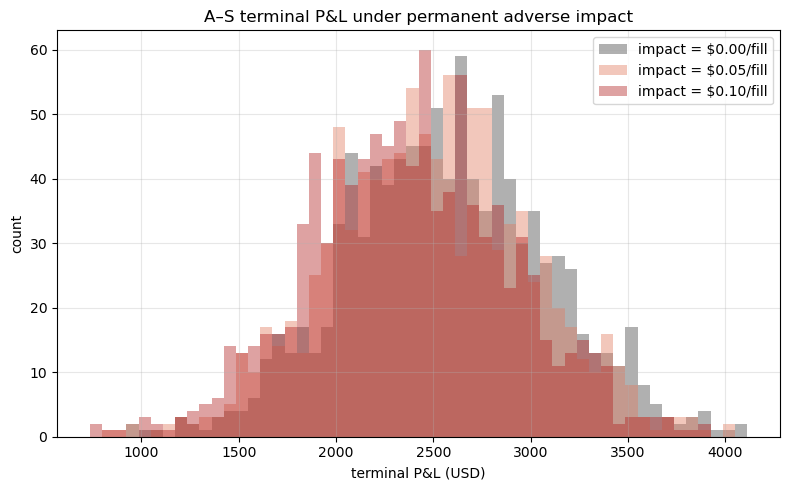

In [4]:
fig, ax = plt.subplots()
colors = ['#444444', '#e07a5f', '#b22222']
bins = np.linspace(
    min(r.terminal_pnl.min() for r in results),
    max(r.terminal_pnl.max() for r in results),
    55,
)
for result, color in zip(results, colors):
    ax.hist(result.terminal_pnl, bins=bins, alpha=0.42, color=color,
            label=f'impact = ${result.impact_per_fill:.2f}/fill')
ax.set_xlabel('terminal P&L (USD)')
ax.set_ylabel('count')
ax.set_title('A–S terminal P&L under permanent adverse impact')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'ps3_p5_pnl_distributions.png', dpi=160, bbox_inches='tight')
plt.show()

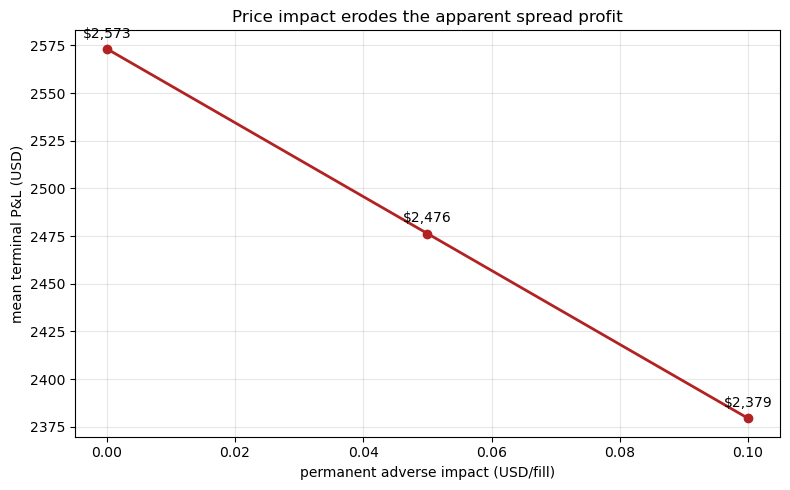

In [5]:
fig, ax = plt.subplots()
ax.plot(summary['impact_usd_per_fill'], summary['mean_pnl'], marker='o', lw=2, color='#b22222')
for _, row in summary.iterrows():
    ax.annotate(f"${row['mean_pnl']:,.0f}",
                (row['impact_usd_per_fill'], row['mean_pnl']),
                xytext=(0, 8), textcoords='offset points', ha='center')
ax.set_xlabel('permanent adverse impact (USD/fill)')
ax.set_ylabel('mean terminal P&L (USD)')
ax.set_title('Price impact erodes the apparent spread profit')
fig.tight_layout()
fig.savefig(FIG_DIR / 'ps3_p5_mean_pnl_degradation.png', dpi=160, bbox_inches='tight')
plt.show()

## 5 · Interpretation

The zero-impact row reproduces the Problem 3 independence assumption. Positive impact shifts the entire P&L distribution left: every fill is followed by a move against the position just acquired, so some quoted-spread revenue was illusory. Because the A–S quote distances depend on inventory but not on the absolute mid level, common random numbers produce the same fill and inventory paths across these linear-impact scenarios; the change is specifically mark-to-market P&L.

With this seed and calibration, $0.05 per fill reduces mean terminal P&L by about 3.8%, while $0.10 per fill reduces it by about 7.5%. The nearly linear degradation is expected from a linear permanent-impact rule. The conclusion is that the original policy remains profitable at the tested levels, but overstates profitability when it treats its own fills as independent of subsequent price changes.